### Data Preprocessing

The dataset is loaded and preprocessed by:
- Normalizing pixel values
- Converting labels into binary classes (0 vs not 0)
- Splitting data into training, validation, and test sets
- Applying feature extraction methods such as flattening, PCA, or HOG

This step prepares the data for efficient model training.

In [1]:
from preprocessing import preprocess
X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="pca", n_pca=100)

Loading MNIST dataset...
Split completed: Train=10660, Val=1185, Test=10000


 ## Model

In [2]:
import numpy as np

class LogisticRegression:
    def __init__(self, lr=0.05, iterations=300, use_weights=True):
        self.lr = lr
        self.iterations = iterations
        self.use_weights = use_weights
        self.w = None
        self.b = None

    # Converts linear output into probability (0 to 1)
    def sigmoid(self, z):
        # z shape: (n_samples,)
        return 1.0 / (1 + np.exp(-z))  # output shape: (n_samples,)
    
    # Compute binary cross-entropy loss
    def compute_loss(self, y, y_hat, weights):
          # y shape: (n_samples,)
          # y_hat shape: (n_samples,)
        epsilon = 1e-15 # small value to avoid log(0)
        y_hat = np.clip(y_hat, epsilon, 1 - epsilon)  
        if self.use_weights and weights is not None:
            loss = - (
                weights[1] * y * np.log(y_hat) +  # loss for class 1
                weights[0] * (1 - y) * np.log(1 - y_hat)  # loss for class 0
            )
        else:
            # standard binary cross-entropy
            loss = - (
                y * np.log(y_hat) +
                (1 - y) * np.log(1 - y_hat)
            )

        return np.mean(loss) # scalar

    def compute_gradients(self, X, y, y_hat, weights):
        # X shape: (n_samples, n_features)
        # y shape: (n_samples,)
        # y_hat shape: (n_samples,)
        m = len(y)

        if self.use_weights and weights is not None:
            sample_weights = np.where(y == 1, weights[1], weights[0])
            error = (y_hat - y) * sample_weights
        else:
            error = (y_hat - y)

        # gradient of loss w.r.t weights
        dw = (1 / m) * (X.T @ error)

        # gradient of loss w.r.t bias
        db = (1 / m) * np.sum(error)

        return dw, db

    def fit(self, X, y, weights=None):
        # X shape: (n_samples, n_features)
        # y shape: (n_samples,)
        n_features = X.shape[1]

        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.iterations):
            z = X @ self.w + self.b
            y_hat = self.sigmoid(z)  # predicted probabilities


            # Loss
            loss = self.compute_loss(y, y_hat, weights)

            # Gradients
            dw, db = self.compute_gradients(X, y, y_hat, weights)

            # update parameters using gradient descent
            self.w -= self.lr * dw
            self.b -= self.lr * db

            if i % 100 == 0:
                print(f"Iteration {i}, Loss: {loss:.4f}")

    def predict(self, X):
        z = X @ self.w + self.b
        y_hat = self.sigmoid(z)
        # apply threshold (0.3 instead of 0.5 for imbalanced data)
        return (y_hat >= 0.3).astype(int)

In [3]:
# Create model object 
model = LogisticRegression(lr=0.1, iterations=1200,use_weights=True)

# Train
model.fit(X_train, y_train, weights)

# Validation performance
y_val_pred = model.predict(X_val)

# Test performance
y_test_pred = model.predict(X_test)

Iteration 0, Loss: 0.6931
Iteration 100, Loss: 0.1131
Iteration 200, Loss: 0.0907
Iteration 300, Loss: 0.0807
Iteration 400, Loss: 0.0748
Iteration 500, Loss: 0.0709
Iteration 600, Loss: 0.0680
Iteration 700, Loss: 0.0659
Iteration 800, Loss: 0.0641
Iteration 900, Loss: 0.0627
Iteration 1000, Loss: 0.0616
Iteration 1100, Loss: 0.0606


In [4]:
def evaluate(X, y, model, dataset_name="Validation"):
    y_pred = model.predict(X)
    y_true = y

    # Positive class = 0 (digit zero)
    TP = np.sum((y_pred == 0) & (y_true == 0))
    TN = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 0) & (y_true == 1))
    FN = np.sum((y_pred == 1) & (y_true == 0))

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    print(f"--- {dataset_name} Results ---")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print("Confusion Matrix:")
    print(f"                 Predicted 0   Predicted 1")
    print(f"  Actual 0   :   {TP:<12}  {FN}")
    print(f"  Actual 1   :   {FP:<12}  {TN}")

In [5]:
# Evaluate
evaluate(X_val, y_val, model, "Validation")
evaluate(X_test, y_test, model, "Test")
from preprocessing import (
    preprocess,
    custom_classification_report,
    custom_confusion_matrix,
    custom_accuracy_score
)
y_pred = model.predict(X_test)


print("\n" + "="*45)
print("  CUSTOM MODEL TEST PERFORMANCE (FLATTEN)")
print("="*45)

target_names = ["0 (Class 0)", "Not 0 (Class 1)"]
print(custom_classification_report(y_test, y_pred, target_names=target_names))

cm = custom_confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (rows = actual, cols = predicted):\n")

--- Validation Results ---
Accuracy  : 0.9789
Precision : 0.9912
Recall    : 0.9658
F1-Score  : 0.9783
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   564           20
  Actual 1   :   5             596
--- Test Results ---
Accuracy  : 0.9871
Precision : 0.9003
Recall    : 0.9765
F1-Score  : 0.9369
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   957           23
  Actual 1   :   106           8914

  CUSTOM MODEL TEST PERFORMANCE (FLATTEN)
                 precision     recall   f1-score    support

0 (Class 0)           0.90       0.98       0.94        980
Not 0 (Class 1)       1.00       0.99       0.99       9020

accuracy                                    0.99      10000
macro avg             0.95       0.98       0.96      10000


Confusion Matrix (rows = actual, cols = predicted):



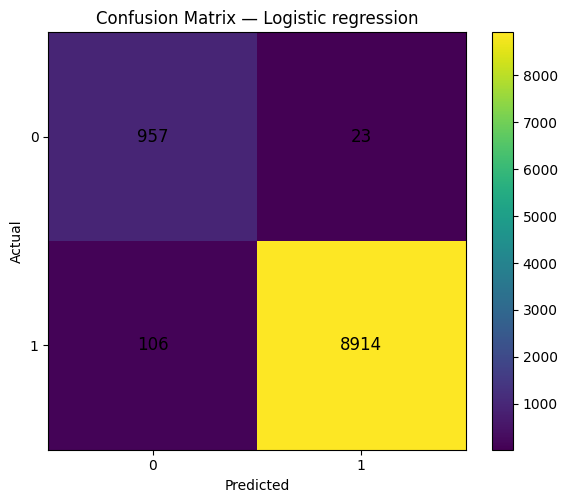

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, class_labels):
    plt.figure(figsize=(6, 5))
    
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix — Logistic regression")
    plt.colorbar()

    tick_marks = np.arange(len(class_labels))
    plt.xticks(tick_marks, class_labels)
    plt.yticks(tick_marks, class_labels)

    # Annotate values inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha="center", va="center",
                     color="black", fontsize=12)

    plt.ylabel("Actual")
    plt.xlabel("Predicted")

    plt.tight_layout()
    plt.show()


# Call it
plot_confusion_matrix(cm, ["0", "1"])

### augmented

In [4]:
from preprocessing import  custom_confusion_matrix, custom_classification_report,preprocess
import numpy as np

X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="pca",balance=False,augment=True)
model = LogisticRegression(lr=0.1, iterations=1200,use_weights=False)

# Train
model.fit(X_train, y_train)



evaluate(X_val, y_val, model, "Validation")
evaluate(X_test, y_test, model, "Test")

Loading MNIST dataset...
Augmenting data to balance classes...
Split completed: Train=97328, Val=6000, Test=10000
Iteration 0, Loss: 0.6931
Iteration 100, Loss: 0.1853
Iteration 200, Loss: 0.1636
Iteration 300, Loss: 0.1542
Iteration 400, Loss: 0.1489
Iteration 500, Loss: 0.1456
Iteration 600, Loss: 0.1433
Iteration 700, Loss: 0.1416
Iteration 800, Loss: 0.1404
Iteration 900, Loss: 0.1394
Iteration 1000, Loss: 0.1387
Iteration 1100, Loss: 0.1381
--- Validation Results ---
Accuracy  : 0.9705
Precision : 0.7895
Recall    : 0.9523
F1-Score  : 0.8633
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   559           28
  Actual 1   :   149           5264
--- Test Results ---
Accuracy  : 0.9745
Precision : 0.8064
Recall    : 0.9735
F1-Score  : 0.8821
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   954           26
  Actual 1   :   229           8791


In [12]:
# ===== K-Fold Cross Validation using custom k_fold_indices =====
from preprocessing import k_fold_indices, get_class_weights, custom_accuracy_score, custom_classification_report

k = 3
folds = k_fold_indices(X_train, k)

accuracies = []

for i, (train_idx, val_idx) in enumerate(folds):
    print(f"\n===== Fold {i+1} =====")
    
    # Split data
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # Recompute class weights for this fold
    weights_fold = get_class_weights(y_train_fold)
    
    # ===== CREATE MODEL OBJECT =====
    model = LogisticRegression(
         lr=0.1,
         iterations=800
    )
    
    # Train model
    model.fit(X_train_fold, y_train_fold, weights_fold)
    
    # Predict
    y_pred = model.predict(X_val_fold)
    
    # Evaluate
    acc = custom_accuracy_score(y_val_fold, y_pred)
    accuracies.append(acc)
    
    print(f"Accuracy: {acc:.4f}")
    
    print("\nClassification Report:")
    print(custom_classification_report(
        y_val_fold, y_pred,
        target_names=["Zero (0)", "Not Zero (1)"]
    ))

# ===== Final Results =====
print("\n===== Final Average Results =====")
print(f"Average Accuracy: {np.mean(accuracies):.4f}")


===== Fold 1 =====
Iteration 0, Loss: 0.6931
Iteration 100, Loss: 0.1126
Iteration 200, Loss: 0.0903
Iteration 300, Loss: 0.0804
Iteration 400, Loss: 0.0745
Iteration 500, Loss: 0.0706
Iteration 600, Loss: 0.0678
Iteration 700, Loss: 0.0656
Accuracy: 0.9747

Classification Report:
                 precision     recall   f1-score    support

Zero (0)              0.99       0.95       0.97       1791
Not Zero (1)          0.96       0.99       0.97       1763

accuracy                                    0.97       3554
macro avg             0.98       0.97       0.97       3554


===== Fold 2 =====
Iteration 0, Loss: 0.6931
Iteration 100, Loss: 0.1115
Iteration 200, Loss: 0.0894
Iteration 300, Loss: 0.0795
Iteration 400, Loss: 0.0736
Iteration 500, Loss: 0.0696
Iteration 600, Loss: 0.0666
Iteration 700, Loss: 0.0644
Accuracy: 0.9755

Classification Report:
                 precision     recall   f1-score    support

Zero (0)              0.99       0.96       0.98       1804
Not Zero (